# ML PROJECT 2
# REGRESSION DATASET : TEXAS_REAL_ESTATE_DATASET

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import SMOTE
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
--- DATA LOAD ---

In [2]:
df=pd.read_csv("C:/Users/YUKESH/Downloads/Texas_real_estate_dataset.csv")
df

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,year_built,Price_Per_SqFt
0,single_family,499000,2040,2,3,3,2,2,2021,245
1,single_family,494500,3674,2,6,4,3,3,2025,135
2,single_family,229000,1650,2,3,3,2,2,2020,139
3,single_family,260000,1741,1,3,2,2,2,2005,149
4,single_family,334990,2255,2,4,4,3,3,2025,149
...,...,...,...,...,...,...,...,...,...,...
12132,condos,222000,1495,2,2,3,2,2,1968,148
12133,single_family,459900,2414,2,4,3,2,2,2021,191
12134,single_family,405000,3428,2,4,4,3,3,1984,118
12135,single_family,399000,1260,1,3,2,2,2,2008,317


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12137 entries, 0 to 12136
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   type             12137 non-null  object
 1   listPrice        12137 non-null  int64 
 2   sqft             12137 non-null  int64 
 3   stories          12137 non-null  int64 
 4   beds             12137 non-null  int64 
 5   baths            12137 non-null  int64 
 6   baths_full       12137 non-null  int64 
 7   baths_full_calc  12137 non-null  int64 
 8   year_built       12137 non-null  int64 
 9   Price_Per_SqFt   12137 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 948.3+ KB


In [4]:
df.corr(numeric_only=True)

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,year_built,Price_Per_SqFt
listPrice,1.000000,0.620915,0.197860,0.256100,0.501631,0.470009,0.469802,0.027463,0.703648
sqft,0.620915,1.000000,0.345895,0.567664,0.714218,0.684636,0.685714,0.080023,0.130682
stories,0.197860,0.345895,1.000000,0.235468,0.458923,0.315764,0.314076,0.133354,0.044950
beds,0.256100,0.567664,0.235468,1.000000,0.644860,0.702519,0.705652,0.159173,-0.050538
baths,0.501631,0.714218,0.458923,0.644860,1.000000,0.873841,0.876242,0.192037,0.165225
baths_full,0.470009,0.684636,0.315764,0.702519,0.873841,1.000000,0.995469,0.177109,0.149581
baths_full_calc,0.469802,0.685714,0.314076,0.705652,0.876242,0.995469,1.000000,0.174759,0.147619
year_built,0.027463,0.080023,0.133354,0.159173,0.192037,0.177109,0.174759,1.000000,-0.014722
Price_Per_SqFt,0.703648,0.130682,0.044950,-0.050538,0.165225,0.149581,0.147619,-0.014722,1.000000


In [ ]:
--- HYPOTHESIS TESTING ---

In [5]:
df["type"].unique()

array(['single_family', 'townhomes', 'multi_family', 'condos',
       'apartment', 'condo_townhome_rowhome_coop'], dtype=object)

In [6]:
import scipy.stats as stats

df['type'] = df['type'].astype('category')

single_family = df[df['type'] == 'single_family']['listPrice']
townhomes = df[df['type'] == 'townhomes']['listPrice']
multi_family = df[df['type'] == 'multi_family']['listPrice']
condos = df[df['type'] == 'condos']['listPrice']
apartment = df[df['type'] == 'apartment']['listPrice']
condo_townhome_rowhome_coop = df[df['type'] == 'condo_townhome_rowhome_coop']['listPrice']
apartment = df[df['type'] == 'apartment']['listPrice']


anova_result = stats.f_oneway(single_family,townhomes,multi_family,condos,apartment,condo_townhome_rowhome_coop,apartment)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes") # there is relationship  # reject the null 
else:
    print("no") # there is no relationship  # accept the null

P-value: 5.935305803021566e-11
yes


In [7]:
hh = LabelEncoder()
df["type"]=hh.fit_transform(df["type"])
df

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,year_built,Price_Per_SqFt
0,4,499000,2040,2,3,3,2,2,2021,245
1,4,494500,3674,2,6,4,3,3,2025,135
2,4,229000,1650,2,3,3,2,2,2020,139
3,4,260000,1741,1,3,2,2,2,2005,149
4,4,334990,2255,2,4,4,3,3,2025,149
...,...,...,...,...,...,...,...,...,...,...
12132,2,222000,1495,2,2,3,2,2,1968,148
12133,4,459900,2414,2,4,3,2,2,2021,191
12134,4,405000,3428,2,4,4,3,3,1984,118
12135,4,399000,1260,1,3,2,2,2,2008,317


In [ ]:
--- HANDLING NULL VALUES ---

In [8]:
df.isnull().sum()

type               0
listPrice          0
sqft               0
stories            0
beds               0
baths              0
baths_full         0
baths_full_calc    0
year_built         0
Price_Per_SqFt     0
dtype: int64

In [ ]:
--- IN THIS DATASET, NO MISSING VALUE ARE PRESENT ---

In [ ]:
--- CHECKING THE OUTLIERS ---

<Axes: xlabel='listPrice'>

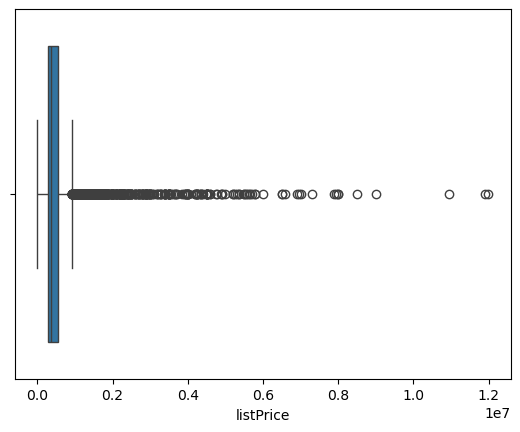

In [9]:
sns.boxplot(x="listPrice",data=df)

<Axes: xlabel='sqft'>

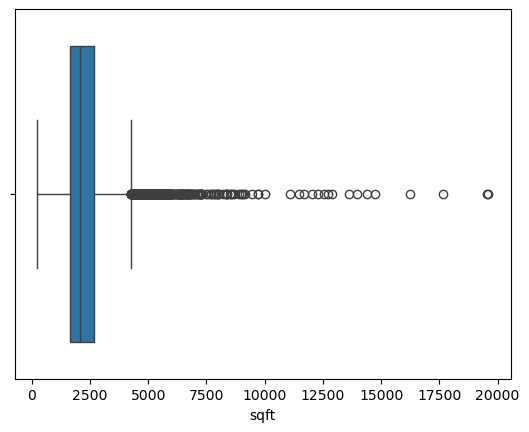

In [10]:
sns.boxplot(x="sqft",data=df)

<Axes: xlabel='stories'>

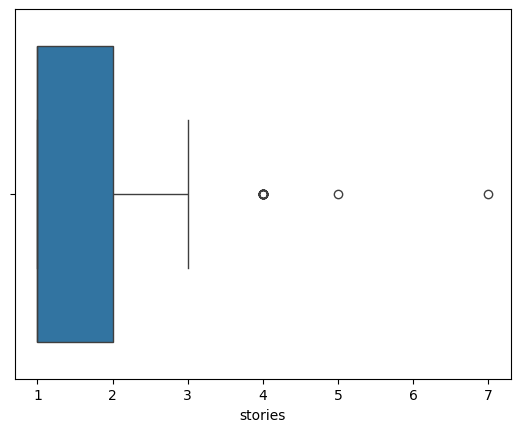

In [11]:
sns.boxplot(x="stories",data=df)

<Axes: xlabel='beds'>

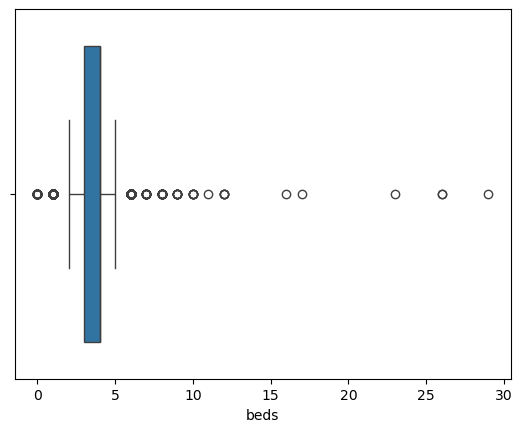

In [12]:
sns.boxplot(x="beds",data=df)

<Axes: xlabel='baths'>

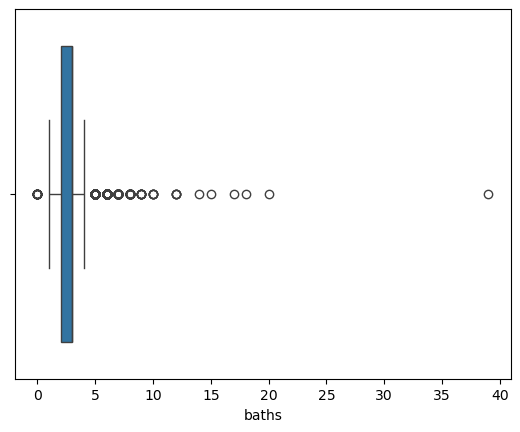

In [13]:
sns.boxplot(x="baths",data=df)

<Axes: xlabel='baths_full'>

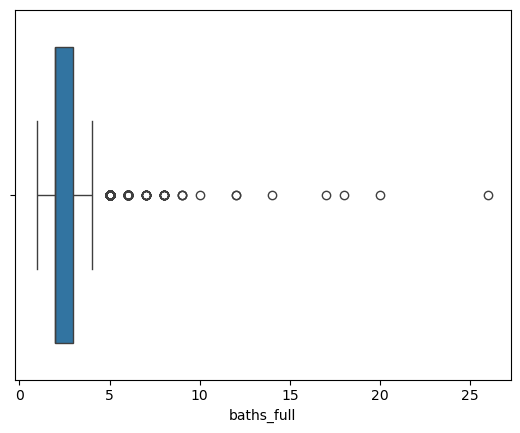

In [14]:
sns.boxplot(x="baths_full",data=df)

<Axes: xlabel='baths_full_calc'>

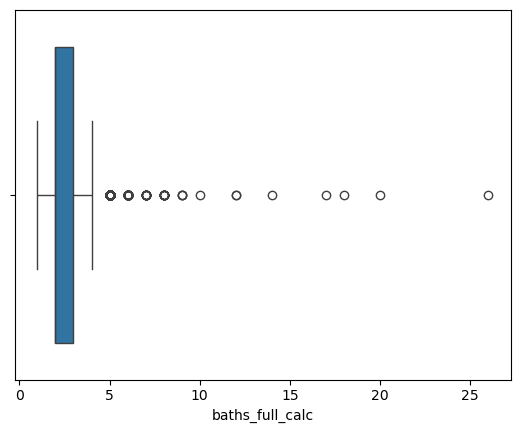

In [15]:
sns.boxplot(x="baths_full_calc",data=df)

<Axes: xlabel='year_built'>

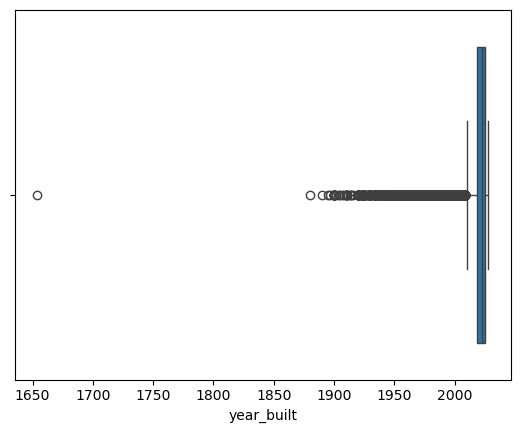

In [16]:
sns.boxplot(x="year_built",data=df)

<Axes: xlabel='Price_Per_SqFt'>

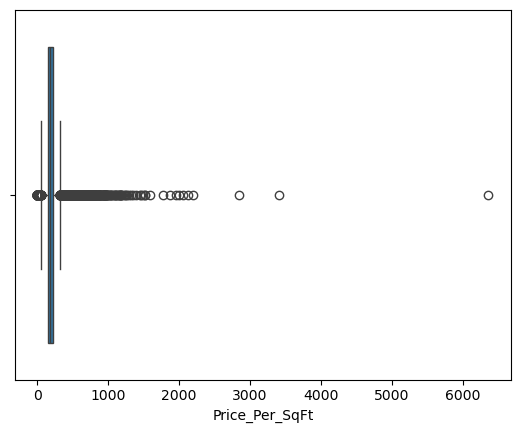

In [17]:
sns.boxplot(x="Price_Per_SqFt",data=df)

In [ ]:
--- SPLITING Y AND X ---

In [18]:
y=df["listPrice"]
y

0        499000
1        494500
2        229000
3        260000
4        334990
          ...  
12132    222000
12133    459900
12134    405000
12135    399000
12136    545000
Name: listPrice, Length: 12137, dtype: int64

In [19]:
x=df.drop("listPrice",axis=1)
x

,type,sqft,stories,beds,baths,baths_full,baths_full_calc,year_built,Price_Per_SqFt
0,4,2040,2,3,3,2,2,2021,245
1,4,3674,2,6,4,3,3,2025,135
2,4,1650,2,3,3,2,2,2020,139
3,4,1741,1,3,2,2,2,2005,149
4,4,2255,2,4,4,3,3,2025,149
...,...,...,...,...,...,...,...,...,...
12132,2,1495,2,2,3,2,2,1968,148
12133,4,2414,2,4,3,2,2,2021,191
12134,4,3428,2,4,4,3,3,1984,118
12135,4,1260,1,3,2,2,2,2008,317


In [ ]:
--- TRAINING PROCESS ---

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- SCALING ---

In [21]:
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [ ]:
--- MODEL 1 ---
--- LINEAR REGRESSION ---

In [27]:
model1=LinearRegression()
model1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
# test_accurarcy
y_pred1=model1.predict(x_test)
accuracy1=r2_score(y_test,y_pred1)
accuracy1

0.801860871477681

In [29]:
# training _accuracy 
y_train_pred1=model1.predict(x_train)
final_training1=r2_score(y_train,y_train_pred1)
final_training1

0.7796181856458988

In [30]:
mae_1 = mean_absolute_error(y_test, y_pred1)
mse_1 = mean_squared_error(y_test, y_pred1)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test, y_pred1)

print("MAE :", mae_1)
print("MSE :", mse_1)
print("RMSE :", rmse_1)
print("R2 Score :", r2_1)

MAE : 86402.15586674503
MSE : 43071495602.1333
RMSE : 207536.73313930066
R2 Score : 0.801860871477681


In [ ]:
--- MODEL 2 ---
--- KNN [K NEAREST NEIGHBORS REGRESSOR] ---

In [31]:
model2=KNeighborsRegressor()
model2.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
# test_accurarcy
y_pred2=model2.predict(x_test)
accuracy2=r2_score(y_test,y_pred2)
accuracy2

0.9192079206490524

In [33]:
# training _accuracy 
y_train_pred2=model2.predict(x_train)
final_training2=r2_score(y_train,y_train_pred2)
final_training2

0.9137848716199444

In [34]:
mae_2 = mean_absolute_error(y_test, y_pred2)
mse_2 = mean_squared_error(y_test, y_pred2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test, y_pred2)

print("MAE :", mae_2)
print("MSE :", mse_2)
print("RMSE :", rmse_2)
print("R2 Score :", r2_2)

MAE : 18616.471004942337
MSE : 17562587038.731037
RMSE : 132523.9111961726
R2 Score : 0.9192079206490524
